In [9]:
# load saved model and artifacts

import json
import joblib
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

# Paths (models is inside notebooks/)
BASE_DIR = Path(".")
MODEL_DIR = BASE_DIR / "models" / "bert_9classes_final"
PROCESSED_DIR = Path("..") / "data" / "processed"

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    str(MODEL_DIR.resolve()),
    local_files_only=True
)
model_rw2 = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR.resolve()),
    local_files_only=True
)

# Load label encoder
le = joblib.load(MODEL_DIR / "label_encoder.joblib")
num_labels = len(le.classes_)

# Load label mapping
with open(MODEL_DIR / "label_mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)
id2label = {int(k): v for k, v in mapping["id2label"].items()}

# Load test data
df_test = pd.read_csv(PROCESSED_DIR / "test.csv")

# Map supercategory
mapping_df = pd.read_csv(PROCESSED_DIR / "label_to_supercategory_v1.csv")
label_to_supercat = dict(zip(mapping_df["label"], mapping_df["supercategory"]))
df_test["supercategory"] = df_test["label"].map(label_to_supercat)
df_test["y"] = le.transform(df_test["supercategory"])

# Device setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_rw2 = model_rw2.to(device)
model_rw2.eval()

print(f"Model loaded from: {MODEL_DIR.resolve()}")
print(f"Device: {device}")
print(f"Num labels: {num_labels}")
print(f"Test samples: {len(df_test)}")

Loading weights: 100%|██████████| 201/201 [00:02<00:00, 87.41it/s, Materializing param=classifier.weight]                                      


Model loaded from: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/models/bert_9classes_final
Device: mps
Num labels: 9
Test samples: 5510


In [10]:
# === Generate predictions for test set ===

def tokenize_fn(batch):
    return tokenizer(
        batch["resume_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

test_dataset = Dataset.from_pandas(df_test[["resume_text", "y"]])
test_dataset = test_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.rename_column("y", "labels")
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

dataloader = DataLoader(test_dataset, batch_size=32)
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        outputs = model_rw2(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_true_rw2 = np.array(all_labels)
y_pred_rw2 = np.array(all_preds)

accuracy = (y_true_rw2 == y_pred_rw2).mean()
print(f"Test Accuracy: {accuracy:.4f}")

Inference: 100%|██████████| 173/173 [03:18<00:00,  1.15s/it]

Test Accuracy: 0.6085


In [11]:
# robust fairness (city n >= 50)

def filter_groups_by_min_n(df, group_col, min_n=50):
    counts = df[group_col].value_counts(dropna=False)
    keep = counts[counts >= min_n].index
    df_f = df[df[group_col].isin(keep)].copy()
    return df_f, counts, keep

In [12]:
# sqrt reweighting (1 / sqrt(n))

def compute_sqrt_inverse_weights(city_series):
    city_counts = city_series.value_counts()
    raw_w = 1.0 / np.sqrt(city_counts)
    norm_w = raw_w / raw_w.mean()
    return norm_w

In [13]:
# fairness helper functions (gap/tpr/fpr)

def gap_by_group(df, group_col):
    """
    Accuracy gap:
    max_group_accuracy - min_group_accuracy
    """
    group_acc = (
        df.groupby(group_col)["correct"]
        .mean()
        .dropna()
    )
    
    if len(group_acc) == 0:
        return np.nan
    
    return group_acc.max() - group_acc.min()


def ovr_rates_by_group(df, group_col, num_classes):
    """
    Computes one-vs-rest TPR and FPR for each class and group.

    Returns:
        tpr: array (num_groups, num_classes)
        fpr: array (num_groups, num_classes)
        support_pos: number of positive samples per (group, class)
        support_neg: number of negative samples per (group, class)
    """
    
    groups = sorted(df[group_col].dropna().unique())
    group_index = {g: i for i, g in enumerate(groups)}
    
    tpr = np.zeros((len(groups), num_classes))
    fpr = np.zeros((len(groups), num_classes))
    support_pos = np.zeros((len(groups), num_classes))
    support_neg = np.zeros((len(groups), num_classes))
    
    for g in groups:
        df_g = df[df[group_col] == g]
        gi = group_index[g]
        
        y_true = df_g["y_true"].values
        y_pred = df_g["y_pred"].values
        
        for c in range(num_classes):
            # Positive = class c
            pos_mask = (y_true == c)
            neg_mask = (y_true != c)
            
            TP = np.sum((y_pred == c) & pos_mask)
            FP = np.sum((y_pred == c) & neg_mask)
            FN = np.sum((y_pred != c) & pos_mask)
            TN = np.sum((y_pred != c) & neg_mask)
            
            support_pos[gi, c] = np.sum(pos_mask)
            support_neg[gi, c] = np.sum(neg_mask)
            
            # TPR = TP / (TP + FN)
            if (TP + FN) > 0:
                tpr[gi, c] = TP / (TP + FN)
            else:
                tpr[gi, c] = np.nan
            
            # FPR = FP / (FP + TN)
            if (FP + TN) > 0:
                fpr[gi, c] = FP / (FP + TN)
            else:
                fpr[gi, c] = np.nan
    
    return tpr, fpr, support_pos, support_neg


def summarize_gaps(rate_matrix):
    """
    Given rate matrix (num_groups, num_classes),
    computes:
        - gap per class
        - worst class gap
        - macro gap (mean over classes)
    """
    
    gap_per_class = []
    
    for c in range(rate_matrix.shape[1]):
        col = rate_matrix[:, c]
        col = col[~np.isnan(col)]
        
        if len(col) == 0:
            gap_per_class.append(np.nan)
        else:
            gap_per_class.append(np.max(col) - np.min(col))
    
    gap_per_class = np.array(gap_per_class)
    
    valid = gap_per_class[~np.isnan(gap_per_class)]
    
    if len(valid) == 0:
        return gap_per_class, np.nan, np.nan
    
    worst_gap = np.max(valid)
    macro_gap = np.mean(valid)
    
    return gap_per_class, worst_gap, macro_gap

In [14]:
# unified evaluation function

from sklearn.metrics import accuracy_score, f1_score

def evaluate_all(df_test, y_true, y_pred, num_classes, min_city_n=50):
    df_eval = df_test.copy()
    df_eval["y_true"] = y_true
    df_eval["y_pred"] = y_pred
    df_eval["correct"] = (df_eval["y_true"] == df_eval["y_pred"])

    out = {}
    out["acc"] = float(accuracy_score(y_true, y_pred))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    # Accuracy gaps
    out["gap_acc_gender"] = float(gap_by_group(df_eval, "gender"))
    out["gap_acc_age"]    = float(gap_by_group(df_eval, "age_group"))
    out["gap_acc_city"]   = float(gap_by_group(df_eval, "city_group"))

    # OVR gaps (full)
    for col in ["gender", "age_group", "city_group"]:
        tpr, fpr, _, _ = ovr_rates_by_group(df_eval, col, num_classes)
        _, tpr_worst, tpr_macro = summarize_gaps(tpr)
        _, fpr_worst, fpr_macro = summarize_gaps(fpr)
        out[f"{col}_tpr_gap_macro"] = tpr_macro
        out[f"{col}_tpr_gap_worst"] = tpr_worst
        out[f"{col}_fpr_gap_macro"] = fpr_macro
        out[f"{col}_fpr_gap_worst"] = fpr_worst

    # Robust city only
    df_city_rob, city_counts, keep = filter_groups_by_min_n(df_eval, "city_group", min_city_n)
    tpr_r, fpr_r, _, _ = ovr_rates_by_group(df_city_rob, "city_group", num_classes)
    _, tpr_worst_r, tpr_macro_r = summarize_gaps(tpr_r)
    _, fpr_worst_r, fpr_macro_r = summarize_gaps(fpr_r)

    out["city_robust_min_n"] = int(min_city_n)
    out["city_robust_num_groups"] = int(len(keep))
    out["city_robust_rows"] = int(len(df_city_rob))
    out["city_robust_tpr_gap_macro"] = tpr_macro_r
    out["city_robust_tpr_gap_worst"] = tpr_worst_r
    out["city_robust_fpr_gap_macro"] = fpr_macro_r
    out["city_robust_fpr_gap_worst"] = fpr_worst_r

    return out

In [15]:
# evaluate final model

MIN_CITY_N = 50

res_final = evaluate_all(df_test, y_true_rw2, y_pred_rw2, num_labels, min_city_n=MIN_CITY_N)

results = pd.DataFrame([{"model": "sqrt_rw_2ep", **res_final}])

results

,model,acc,macro_f1,gap_acc_gender,gap_acc_age,gap_acc_city,gender_tpr_gap_macro,gender_tpr_gap_worst,gender_fpr_gap_macro,gender_fpr_gap_worst,...,city_group_tpr_gap_worst,city_group_fpr_gap_macro,city_group_fpr_gap_worst,city_robust_min_n,city_robust_num_groups,city_robust_rows,city_robust_tpr_gap_macro,city_robust_tpr_gap_worst,city_robust_fpr_gap_macro,city_robust_fpr_gap_worst
0,sqrt_rw_2ep,0.60853,0.620627,0.049549,0.156493,0.6,0.04458,0.066558,0.006095,0.023507,...,1.0,0.159893,0.444444,50,14,4743,0.748316,1.0,0.091039,0.256291


In [16]:
# worst-case city × class diagnostics

df_eval = df_test.copy()
df_eval["y_true"] = y_true_rw2
df_eval["y_pred"] = y_pred_rw2

rows = []

for c in range(num_labels):

    df_c = df_eval.copy()

    df_c["is_pos"] = (df_c["y_true"] == c).astype(int)
    df_c["is_tp"] = ((df_c["y_true"] == c) & (df_c["y_pred"] == c)).astype(int)

    stats = df_c.groupby("city_group").agg(
        positives=("is_pos", "sum"),
        tp=("is_tp", "sum")
    )

    stats["tpr"] = stats["tp"] / stats["positives"]

    # минимальный support по классу
    stats = stats[stats["positives"] >= 5]

    if len(stats) == 0:
        continue

    worst_city = stats["tpr"].idxmin()
    best_city = stats["tpr"].idxmax()

    rows.append({
        "class_id": c,
        "class_name": le.inverse_transform([c])[0],
        "worst_city": worst_city,
        "best_city": best_city,
        "TPR_worst": stats.loc[worst_city, "tpr"],
        "TPR_best": stats.loc[best_city, "tpr"],
        "support_worst": stats.loc[worst_city, "positives"],
        "support_best": stats.loc[best_city, "positives"]
    })

worst_case_table = pd.DataFrame(rows)

worst_case_table["tpr_gap"] = (
    worst_case_table["TPR_best"] - worst_case_table["TPR_worst"]
)

worst_case_table = worst_case_table.sort_values(
    "tpr_gap",
    ascending=False
)

worst_case_table

,class_id,class_name,worst_city,best_city,TPR_worst,TPR_best,support_worst,support_best,tpr_gap
3,3,project_product,Тюмень,Алматы,0.166667,1.000000,6,11,0.833333
7,7,technical_specialized,Самара,Алматы,0.181818,1.000000,11,7,0.818182
4,4,sales_account,Краснодар,Алматы,0.222222,1.000000,9,5,0.777778
0,0,backend_general_dev,Томск,Алматы,0.285714,1.000000,7,8,0.714286
1,1,generic_it_ops,Тюмень,Иркутск,0.333333,1.000000,9,6,0.666667
2,2,it_governance_leadership,Пермь,Уфа,0.333333,1.000000,6,6,0.666667
6,6,tech_support_helpdesk,Нижний Новгород,Краснодар,0.125000,0.666667,8,6,0.541667
5,5,sysadmin_devops_network,Владивосток,Алматы,0.500000,1.000000,6,13,0.500000
8,8,web_frontend,Москва,Новосибирск,0.537313,0.800000,67,5,0.262687


In [17]:
# save worst-case TPR gap analysis by city group

worst_case_table.to_csv(
    "../figures/city_worst_case_analysis.csv",
    index=False
)

In [18]:
# filter robust cases

robust_table = worst_case_table[
    worst_case_table["support_worst"] >= 30
]

robust_table

,class_id,class_name,worst_city,best_city,TPR_worst,TPR_best,support_worst,support_best,tpr_gap
8,8,web_frontend,Москва,Новосибирск,0.537313,0.8,67,5,0.262687


In [19]:
# label prediction errors for frontend

frontend_class = le.transform(["web_frontend"])[0]

df_front = df_test.copy()
df_front["y_true"] = y_true_rw2
df_front["y_pred"] = y_pred_rw2

df_front = df_front[
    (df_front["y_true"] == frontend_class) &
    (df_front["city_group"] == "Москва")
]

df_front["correct"] = df_front["y_true"] == df_front["y_pred"]

df_front["correct"].value_counts()

correct
True     36
False    31
Name: count, dtype: int64

In [20]:
# analyze frontend misclassification examples
errors_front = df_front[df_front["correct"] == False]

errors_front[["resume_text", "y_pred"]].head(10)

,resume_text,y_pred
295,Опыт работы 6 лет Май 2018 — по настоящее врем...,3
563,Опыт работы 10 лет 11 месяцев Февраль 2019 — п...,3
727,Опыт работы 3 месяца Июнь 2018 — Август 2018 3...,1
1070,Опыт работы 12 лет Октябрь 2018 — Декабрь 2018...,5
1611,Опыт работы 9 лет 11 месяцев Август 2017 — по ...,7
1836,Опыт работы 10 лет 11 месяцев Апрель 2016 — по...,1
1909,Опыт работы 18 лет 1 месяц Июль 2006 — по наст...,3
1921,Опыт работы 9 лет 10 месяцев Декабрь 2006 — Се...,3
2152,Опыт работы 9 лет 6 месяцев Декабрь 2009 — по ...,5
2352,Опыт работы 3 месяца Август 2018 — Октябрь 201...,7


In [21]:
# most common error words

from collections import Counter
import re

texts = errors_front["resume_text"].tolist()

words = []

for t in texts:
    tokens = re.findall(r"\b\w+\b", t.lower())
    words.extend(tokens)

top_words = Counter(words).most_common(30)

top_words

[('и', 429),
 ('с', 140),
 ('ru', 116),
 ('в', 112),
 ('по', 106),
 ('интернет', 103),
 ('месяцев', 101),
 ('разработка', 99),
 ('на', 95),
 ('москва', 85),
 ('работы', 67),
 ('для', 66),
 ('интеграция', 63),
 ('3', 55),
 ('системная', 55),
 ('1', 54),
 ('2', 54),
 ('www', 52),
 ('технологии', 52),
 ('системы', 51),
 ('дизайн', 50),
 ('сайтов', 49),
 ('опыт', 48),
 ('месяца', 48),
 ('компании', 48),
 ('информационные', 48),
 ('ооо', 47),
 ('web', 45),
 ('года', 44),
 ('сайта', 40)]

In [22]:
# frontend error word analysis cell

df_eval = df_test.copy()
df_eval["y_true"] = y_true_rw2
df_eval["y_pred"] = y_pred_rw2

rows = []

for c in range(num_labels):

    df_c = df_eval.copy()

    df_c["is_pos"] = (df_c["y_true"] == c).astype(int)
    df_c["is_tp"] = ((df_c["y_true"] == c) & (df_c["y_pred"] == c)).astype(int)

    stats = df_c.groupby("city_group").agg(
        positives=("is_pos", "sum"),
        tp=("is_tp", "sum")
    )

    stats["tpr"] = stats["tp"] / stats["positives"]

    stats = stats.reset_index()
    stats["class"] = le.inverse_transform([c])[0]

    rows.append(stats)

heatmap_df = pd.concat(rows)

In [23]:
# tpr pivot by city class

pivot = heatmap_df.pivot(
    index="city_group",
    columns="class",
    values="tpr"
)

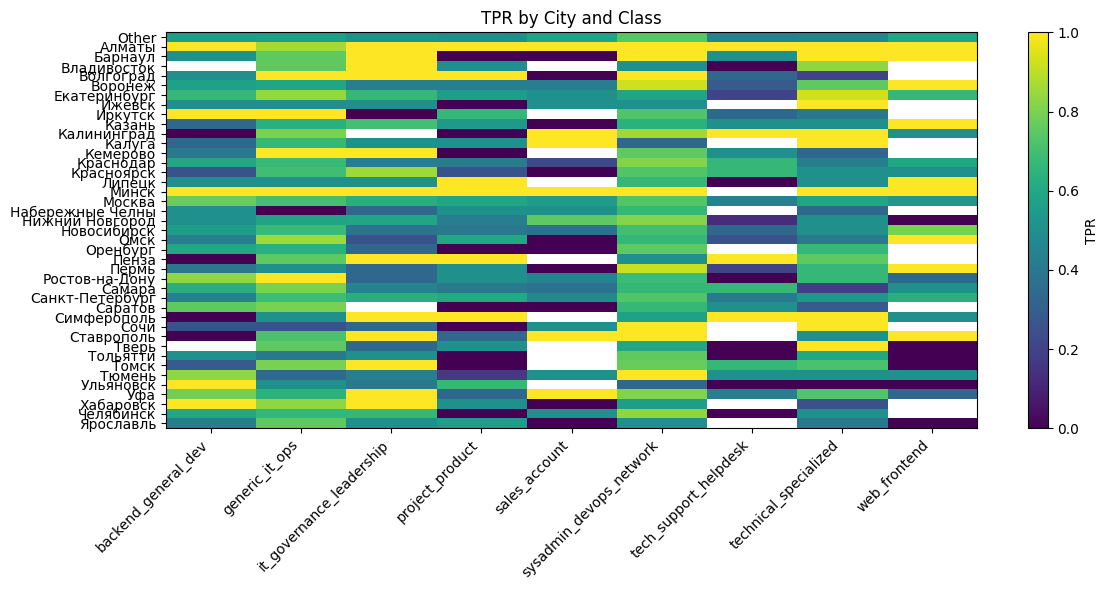

In [24]:
# city class tpr heatmap visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.imshow(pivot, aspect="auto")

plt.colorbar(label="TPR")

plt.xticks(
    np.arange(len(pivot.columns)),
    pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(pivot.index)),
    pivot.index
)

plt.title("TPR by City and Class")

plt.tight_layout()
plt.show()

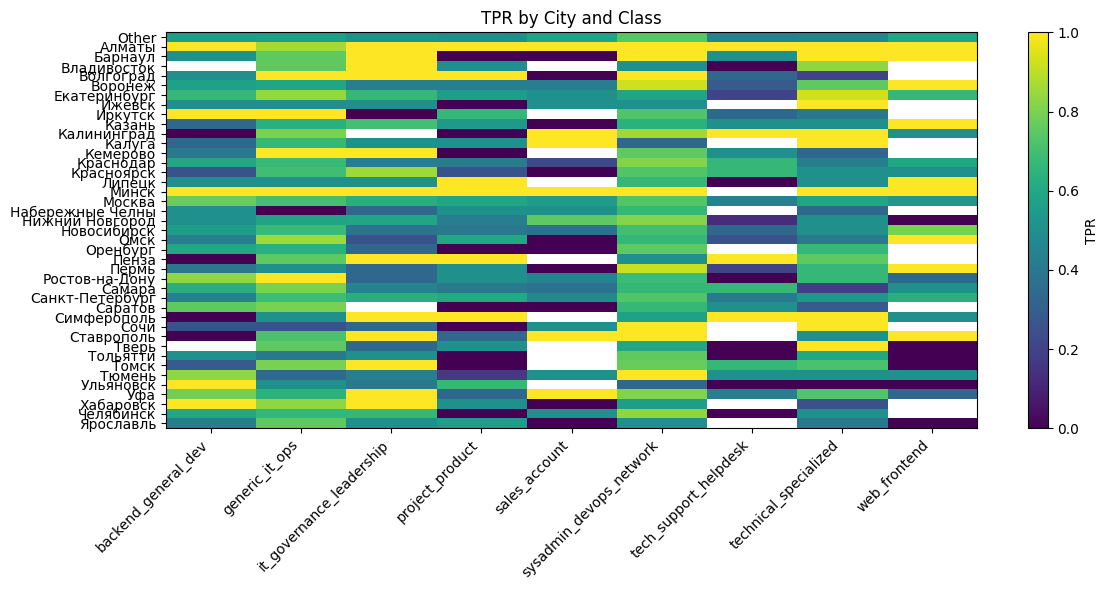

In [25]:
# save city class tpr heatmap
plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="TPR")
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(pivot.index)), pivot.index)
plt.title("TPR by City and Class")
plt.tight_layout()
plt.savefig("../figures/city_class_tpr_heatmap.png", dpi=300)
plt.show()